In [1]:
from langchain_qdrant import QdrantVectorStore, FastEmbedSparse
from qdrant_client import QdrantClient
from dotenv import load_dotenv
import os
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.tools import WikipediaQueryRun
from langchain_tavily import TavilySearch
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import Tool

from dataclasses import dataclass
from pydantic import BaseModel, Field
from typing import List
from langchain_core.documents import Document

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
load_dotenv()
import ast


c:\RAG\Bots\ReActBot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class ProcessLoader:

    def __init__(self):
        self.client = QdrantClient(
                            url=os.getenv('QDRANT_API_URL'),
                            api_key=os.getenv('QDRANT_API_KEY')
                        )
        self.dense_embedding = HuggingFaceEmbeddings(model = 'sentence-transformers/all-MiniLM-L12-v2')
        self.sparse_embedding = FastEmbedSparse(model_name ='Qdrant/bm25')
        
        self.qdrantdb = QdrantVectorStore(
            client=self.client,
            collection_name= os.getenv('COLLECTIONNAME'),
            embedding=self.dense_embedding,
            sparse_embedding=self.sparse_embedding
        )
        self.wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results= 5, doc_content_chars_max= 2000))
        self.tavily_tool = TavilySearch(
            max_results=5,
            topic="general",
        )

    @property
    def getPBIRetriver(self):

        return self.qdrantdb.as_retriever(
            search_type = 'mmr',
                search_kwarg = {
                    "k":10
                }
        )
    
    


In [3]:
llm = ChatGroq(model='qwen/qwen3-32b')
pbi_obj = ProcessLoader()
pbi_retriver = pbi_obj.getPBIRetriver


In [4]:
# @dataclass
class IterativeSelfReflection(BaseModel):

    question: str
    refinedQuestion : List[str] = []
    retrivedDocs : List[Document] = []
    answer: str
    reflection : str
    revised : int
    attempts: int = 0

In [5]:

class DecomposedQueries(BaseModel):
    """List of simple, distinct, and independent sub-questions."""
    refined_queries: List[str] = Field(description="A list of fully independent sub-questions necessary to answer the original complex query."
    )

In [6]:
def generateRetriverDocs(state: IterativeSelfReflection) -> IterativeSelfReflection:

    """ 
    Retrieves relevant documents from a vector store based on a query. 
    This node handles the critical step of fetching context based on question attribute of state.

    :param state: object of ChainOfCmdBot include below members.
                    a. question (String)
                    b. refinedQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
                    e. reflection (String)
                    f. revised (int)
                    g. attempts (int)

    :type : IterativeSelfReflection

    :returs : Object of IterativeSelfReflection type where retrivedDocs will be populated by retriver (pbi_retriver)  
    """
    print('---- In generateRetriverDocs-------')
    results = []
    if len(state.refinedQuestion) == 0:
        results = pbi_retriver.invoke(state.question)
    else:
        for qus in state.refinedQuestion:
            docs = pbi_retriver.invoke(qus)
            results.extend(docs)

    return state.model_copy(update={
                            "retrivedDocs" : results
                            })




In [7]:
def generateAnswer(state: IterativeSelfReflection) -> IterativeSelfReflection:

    """
        Synthesizes the final answer by consolidating retrieved documents.

        This terminal node in the LLM chain takes the list of relevant documents, 
        feeds them into the Language Model (LLM) as context, and prompts the LLM to generate a single, coherent, and
        comprehensive answer that addresses all parts of the original query.

        :param state: object of IterativeSelfReflection include below members.
                    a. question (String)
                    b. refinedQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
                    e. reflection (String)
                    f. revised (int)
                    g. attempts (int)

        :type : IterativeSelfReflection

        :returs : Object of IterativeSelfReflection type where answer will be populated by LLM based on Documents received from retriver (pbi_retriver)  
    """
    print('---- In generateAnswer-------')
    context_documents = "\n\n".join([doc.page_content for doc in state.retrivedDocs])
    prompt = f""" 
             You are an expert Q&A system. Your task is to generate a single, comprehensive, and well-structured answer to the user's original query.

                    **Instructions:**
                    1.  Read the **Original Query** 
                    2.  Carefully analyze the content of the **Context Documents** provided below.
                    3.  Synthesize the information from the documents to construct a complete answer that addresses all parts of the Original Query.
                    4.  Do not introduce any information that is not explicitly present in the Context Documents.
                    5.  Structure your final answer clearly using markdown headings and bullet points where appropriate.
                    6.  Refer Docstring for more details

                    **Original Query:**
                    {state.question}

                    **Context Documents:**
                    {context_documents}

                    **Final Answer:**

            """
    
    result = llm.invoke(prompt).content
    print(result)
    return state.model_copy(
        update={
            "answer": result,
            "attempts" : state.attempts + 1
        }
    )

In [8]:

def reflectionEval(state: IterativeSelfReflection) -> IterativeSelfReflection:

    """ 
    Evaluates and critiques the generated answer against provided context and query.

    This node performs the crucial self-reflection step in the RAG or Agentic workflow.
    It invokes an LLM to act as a 'Critic' or 'Judge', assessing the 'initial_answer'
    for factual grounding (against retrieved_context), completeness (against original_query),
    and adherence to format.

    The primary output is a binary decision or a critique, which is used by the
    LangGraph router to determine the workflow's next step.

    :param state: object of IterativeSelfReflection include below members.
                    a. question (String)
                    b. refinedQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
                    e. reflection (String)
                    f. revised (int)
                    g. attempts (int)

    :type : IterativeSelfReflection    

    :returns ::returs : Object of IterativeSelfReflection type where answer will be evaluated by LLM and populate reflection and revised attributes.
"""
    print('---- In reflectionEval-------')
    
    context_documents = '\n\n'.join([doc.page_content for doc in state.retrivedDocs])
    prompt = f""" 
            **System Instruction: Reflection and Critique**

                Your role is to act as a rigorous, unbiased editor and quality assurance critic for the generated **Initial Answer**. 
                You must evaluate the provided answer against the original **Query** and the **Context** based on the criteria below.

                **Instructions:**
                    1.  **Analyze** the Initial Answer based on the **Evaluation Criteria**.
                    2.  If anything in the question is Not relavent to context then Consider Initial Answer **fails** and output only the single word: **NO**. 
                    3.  If the Initial Answer is **perfect**, output only the single word: **YES**.
                    4.  If the Initial Answer **fails** any criteria, generate a detailed critique.
                    

                **Evaluation Criteria:**
                    * **Completeness:** Does the Initial Answer address **every component** of the Original Query? Are all sub-questions answered?
                    * **Grounding:** Is **all factual information** strictly supported by the **Retrieved Context**? Are any statements speculative or hallucinated?
                    * **Clarity and Coherence:** Is the answer logically structured, easy to read, and free of contradictions or confusing language?
                    * **Format Compliance:** Does the answer adhere to the required output constraints (e.g., specific markdown headings, JSON format, length limits)?

            **Inputs to Evaluate:**

            **Original Query:**
            {state.question}

            **Retrieved Context (The only source of truth):**
            {context_documents}

            **Initial Answer (The output you must critique):**
            {state.answer}

            ---

            **CRITIQUE & REFINEMENT**

            **Critique:** (Provide a detailed, point-by-point analysis based on the Evaluation Criteria. 
                Specify exactly *what* is wrong and *where* in the context the correct information can be found.)

            **Refined Action/Correction:** (Provide precise, actionable steps or corrections required to fix the Initial Answer. 
                If the answer is [FAIL], rewrite the problematic section or clearly indicate the missing information.)
        """
    
    result = llm.invoke(prompt).content
    print(result.lower())
    return state.model_copy(update= {
                                        "reflection": result ,
                                        "revised": 0 if result.lower() == "yes" else 1
                                    } 
                            )
    

In [9]:
def queryPlanner(state: IterativeSelfReflection) -> IterativeSelfReflection:

    """ 
    Analyzes a complex user query and generates an optimal list of sub-queries
    or a single optimized query for the RAG system's retrieval step.

    The Query Planner utilizes an LLM to perform **meta-reasoning** on the initial
    request, breaking down multi-part questions (e.g., "What were the sales for Q4 
    and how did they compare to the marketing budget?") into distinct, retrieval-friendly
    components. This is a critical step in advanced RAG pipelines.

    :param state : object of IterativeSelfReflection include below members.
                    a. question (String)
                    b. refinedQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
                    e. reflection (String)
                    f. revised (int)
                    g. attempts (int)

    :type : IterativeSelfReflection

    :returns : object of IterativeSelfReflection with Modified Value of attributes refinedQuestion.

    :Raises :
        APIError: If the LLM API call fails or returns an error.
        ValueError: If the model_config is invalid or missing required keys.
    """

    print('---- In queryPlanner-------')
    prompt = f""" 
                You are an expert Query Decomposer agent for a Retrieval-Augmented Generation (RAG) system. Your sole function is to analyze a complex, multi-part user question and break it down into a list of simple, distinct, and independent sub-questions that are necessary to fully answer the original query.

                * **Goal:** Create focused, maximum-retrieval sub-queries.
                * **Rule 1 (Independence):** Each sub-question must be answerable on its own.
                * **Rule 2 (Clarity):** Explicitly re-state all subjects and entities in every sub-question. Do not use pronouns.
                * **Rule 3 (Formatting):** Output **ONLY** the list of strings using the provided JSON schema.
                
                **Question**: {state.question}   

                **refinedQuestion**

                Example:
                "What is Power BI"
                ["1. Define Power BI?", "2. Define Power BI Components?","3. Define Power BI Usage?"]

                Please add Questions only in refinedQuestion List not other details. for more details refer function docstring.  

                **Final Answer:**     
            """
    
    structured_llm  = llm.with_structured_output(DecomposedQueries)
    result = structured_llm.invoke(prompt)
    print(result)

    subqus = [qus.strip() for qus in result.refined_queries]
    return state.model_copy(update={
        "refinedQuestion" :  subqus
    })
    
    

In [10]:
def finalize(state: IterativeSelfReflection) -> IterativeSelfReflection:

    """ 
     Finalize the State if Max Attempt Reach or got Correct Answer
    """
    print('---- In finalize-------')
    return state



def decisionFunction(state: IterativeSelfReflection):
    """ 
    A critical component used in reflective AI agent architectures. This node
    evaluates the quality and confidence of a previously generated answer
    (or output) and determines the necessary next step in the workflow.

    It decides whether the answer is satisfactory and ready for final output,
    or if Answer is not satisfactory Generate New Answer.

    :param state: object of IterativeSelfReflection include below members.
                    a. question (String)
                    b. refinedQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
                    e. reflection (String)
                    f. revised (int)
                    g. attempts (int)

    :type : IterativeSelfReflection 

    :returns : String represent Which Function need to call

    """
    print('---- In decisionFunction-------')
    print(state.revised, state.attempts)
    if state.revised == 1 and state.attempts <= 3:
        return "queryPlanner"
    else:
        return "finalize"
        


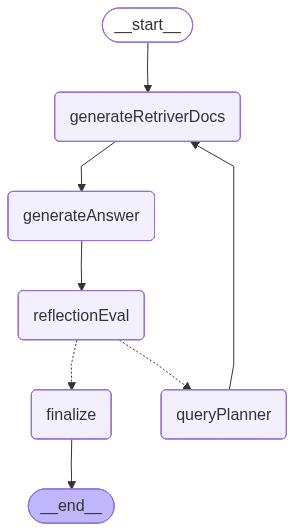

In [11]:
graph = StateGraph(IterativeSelfReflection)

graph.add_node("generateRetriverDocs", generateRetriverDocs)
graph.add_node("generateAnswer", generateAnswer)
graph.add_node("reflectionEval", reflectionEval)
graph.add_node("queryPlanner", queryPlanner)
graph.add_node("finalize", finalize)

graph.set_entry_point("generateRetriverDocs")
graph.add_edge("generateRetriverDocs", "generateAnswer")
graph.add_edge("generateAnswer", "reflectionEval")
graph.add_conditional_edges("reflectionEval",
                            decisionFunction,
                                {
                                    "queryPlanner": "queryPlanner",
                                    "finalize": "finalize"
                                }
                            )
graph.add_edge("queryPlanner","generateRetriverDocs")
graph.add_edge("finalize", END)

graph_builder = graph.compile()
graph_builder


In [12]:
if __name__ == "__main__":
    query = "Difference Between power bi desktop and power bi paginated report"
    state = IterativeSelfReflection(question=query,                            
                            retrivedDocs  = [],
                            answer = "",
                            reflection = "",
                            revised = 1,
                            attempts= 0)
    final = graph_builder.invoke(state)

    print(final['question'])
    print('--------------------------------')
    print(final['answer'])
    print('--------------------------------')

---- In generateRetriverDocs-------
---- In generateAnswer-------
<think>
Okay, so I need to figure out the difference between Power BI Desktop and Power BI Paginated Reports. Let me start by looking at the context documents provided. 

First, there's a document that talks about paginated reports. It says they're called "perfect-pixel" reports and are designed to fit on a page, handling large tables that span multiple pages. They're static, fixed-layout, optimized for printing and PDF/Word exports, and used for operational reporting like invoices and form letters. In contrast, regular Power BI reports are interactive, optimized for on-screen exploration, with flexible layouts and dashboard views.

Another document mentions Power BI Desktop, which I know is the tool you use to create reports. The process is to create the report in Desktop and then publish it to the Power BI Service to share and create dashboards. But the user is asking about the difference between Desktop and paginated 

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `qwen/qwen3-32b` in organization `org_01k9wbkggefz9rdmsfpbjpmvrt` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 7038, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}